# Living off the Land (LotL) Attack Detection using BERT and LOLWTC

This notebook implements two deep learning models for detecting LotL attacks:
1. **BERT** (Bidirectional Encoder Representations from Transformers) with Fully Connected Neural Network
2. **LOLWTC** (LotL Attack Detection Method Based on Word2Vec and TextCNN)

Based on the paper: "LOLWTC: A deep learning approach for detecting Living off the Land attacks" by Kuiye Ding et al.

## 1. Install Required Libraries

In [5]:
# Install required packages
!pip install -q torch torchvision transformers gensim scikit-learn pandas numpy matplotlib seaborn tqdm

## 2. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F

# For BERT
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW

# For Word2Vec
from gensim.models import Word2Vec

# For traditional ML methods (comparison)
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

# For data processing and evaluation
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import LabelEncoder

# Utilities
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
import re
import random
import time

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 3. Load and Preprocess Data

In [7]:
import pandas as pd

# Load the dataset
# Update the path according to your environment
df = pd.read_csv('/content/balanced_combined_lotl_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nClass distribution:")
print(df['Label'].value_counts())
print(f"\nFirst few rows:")
df.head()

Dataset shape: (7049, 2)

Column names:
['Command', 'Label']

Class distribution:
Label
0    6613
1     436
Name: count, dtype: int64

First few rows:


,Command,Label
0,"echo.exe %DATE% %TIME% >> ""C:\Users\jofu\Deskt...",0
1,"findstr /C:""LdM79jy9uwpQ"" ""C:\Windows\rvgnpptq...",0
2,"attrib +h ""C:\AppData\Logs\kbulk.dll""",0
3,"sc query | findstr ""SERVICE_NAME""",0
4,"C:\Windows\System32\attrib.exe +h ""C:\Users\hn...",0


## 4. Feature Engineering (As per Paper Section 2.1)

In [11]:
def extract_manual_features(command):
    """
    Extract manual features as described in the paper Section 2.1
    The paper mentions 14 features total extracted from:
    - Network features (protocols, IP addresses)
    - Binary features (system files exploitable for LotL)
    - KEYWORD_-c (critical -c parameter)
    - COMMAND_INSTALL (install commands)
    """
    command_lower = command.lower()

    features = {}

    # # Network features
    # features['has_http'] = 1 if re.search(r'https?://', command_lower) else 0
    # features['has_ftp'] = 1 if 'ftp' in command_lower else 0
    # features['has_tcp_udp'] = 1 if re.search(r'(tcp|udp)', command_lower) else 0
    # features['has_ip'] = 1 if re.search(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', command) else 0
    # features['has_port'] = 1 if re.search(r':\d{2,5}', command) else 0

    # # Binary/System files that can be exploited
    # system_binaries = ['cmd', 'powershell', 'bash', 'sh', 'python', 'perl', 'ruby',
    #                   'java', 'cscript', 'wscript', 'mshta', 'rundll32', 'regsvr32',
    #                   'certutil', 'bitsadmin', 'curl', 'wget', 'netsh', 'sc']
    # features['has_system_binary'] = 1 if any(bin in command_lower for bin in system_binaries) else 0
    # features['has_shell'] = 1 if re.search(r'(cmd|powershell|bash|sh)\.(exe)?', command_lower) else 0
    # features['has_script_engine'] = 1 if re.search(r'(cscript|wscript|mshta)', command_lower) else 0

    # # KEYWORD_-c parameter (critical in many system files)
    # features['has_c_param'] = 1 if re.search(r'\s-c\s', command) else 0
    # features['has_command_param'] = 1 if re.search(r'(--command|-command|/c)', command_lower) else 0

    # # COMMAND_INSTALL
    # features['has_install'] = 1 if re.search(r'(install|setup|deploy)', command_lower) else 0
    # features['has_download'] = 1 if re.search(r'(download|get|fetch|pull|wget|curl)', command_lower) else 0

    # # Additional features based on common LotL patterns
    # features['has_execute'] = 1 if re.search(r'(exec|execute|run|start|spawn|launch)', command_lower) else 0
    # features['has_base64'] = 1 if re.search(r'base64', command_lower) else 0
    # features['has_encoding'] = 1 if re.search(r'(decode|encode|convert)', command_lower) else 0
    # features['has_hidden'] = 1 if re.search(r'(hidden|hide|stealth)', command_lower) else 0
    # features['has_admin'] = 1 if re.search(r'(admin|administrator|elevated|sudo)', command_lower) else 0
    # features['has_registry'] = 1 if re.search(r'(registry|reg\s|regedit|hklm|hkcu)', command_lower) else 0

    # Command length features
    features['cmd_length'] = len(command)
    features['word_count'] = len(command.split())

    return features

# Text preprocessing function
def preprocess_command(command):
    """Basic text cleaning for command strings"""
    # Convert to lowercase for consistency
    command = command.lower()
    # Normalize path separators
    command = re.sub(r'\\', '/', command)
    # Keep the structure but remove excessive whitespace
    command = ' '.join(command.split())
    return command

# Apply preprocessing and feature extraction
print("Preprocessing commands...")
df['processed_text'] = df['Command'].apply(preprocess_command)

print("Extracting manual features...")
feature_list = df['Command'].apply(lambda x: extract_manual_features(x))
feature_df = pd.DataFrame(list(feature_list))

# Normalize numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
feature_df[['cmd_length', 'word_count']] = scaler.fit_transform(feature_df[['cmd_length', 'word_count']])

print(f"\nExtracted {len(feature_df.columns)} features")
print(f"Feature names: {feature_df.columns.tolist()}")
print(f"\nFeature statistics:")
print(feature_df.describe())

Preprocessing commands...
Extracting manual features...

Extracted 2 features
Feature names: ['cmd_length', 'word_count']

Feature statistics:
         cmd_length    word_count
count  7.049000e+03  7.049000e+03
mean   4.334422e-17 -4.435222e-17
std    1.000071e+00  1.000071e+00
min   -1.437461e+00 -1.000777e+00
25%   -5.355826e-01 -4.315461e-01
50%   -1.573755e-01 -1.469308e-01
75%    2.790174e-01  1.376845e-01
max    2.154589e+01  2.489922e+01


## 5. Data Splitting for Training and Testing

In [12]:
# Prepare data for models
X_text = df['processed_text'].values
X_features = feature_df.values
y = df['Label'].values

# Split data (80-20 split)
X_text_train, X_text_test, X_feat_train, X_feat_test, y_train, y_test = train_test_split(
    X_text, X_features, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training set size: {len(X_text_train)}")
print(f"Test set size: {len(X_text_test)}")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts())

Training set size: 5639
Test set size: 1410

Training set class distribution:
0    5290
1     349
Name: count, dtype: int64

Test set class distribution:
0    1323
1      87
Name: count, dtype: int64


## 6. Traditional ML Methods (For Comparison - Section 2 of Paper)

In [13]:


results = {}

# 1. Bag-of-Words
print("Training with Bag-of-Words...")
bow_vectorizer = CountVectorizer(max_features=5000, token_pattern=r'\b\w+\b')
X_bow_train = bow_vectorizer.fit_transform(X_text_train)
X_bow_test = bow_vectorizer.transform(X_text_test)

# Combine BoW with manual features
X_bow_train_combined = np.hstack([X_bow_train.toarray(), X_feat_train])
X_bow_test_combined = np.hstack([X_bow_test.toarray(), X_feat_test])

rf_bow = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_bow.fit(X_bow_train_combined, y_train)
y_pred_bow = rf_bow.predict(X_bow_test_combined)

results['BoW'] = {
    'accuracy': accuracy_score(y_test, y_pred_bow),
    'precision': precision_score(y_test, y_pred_bow, average='macro'),
    'recall': recall_score(y_test, y_pred_bow, average='macro'),
    'f1': f1_score(y_test, y_pred_bow, average='macro')
}

# 2. TF-IDF
print("Training with TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(max_features=5000, token_pattern=r'\b\w+\b')
X_tfidf_train = tfidf_vectorizer.fit_transform(X_text_train)
X_tfidf_test = tfidf_vectorizer.transform(X_text_test)

# Combine TF-IDF with manual features
X_tfidf_train_combined = np.hstack([X_tfidf_train.toarray(), X_feat_train])
X_tfidf_test_combined = np.hstack([X_tfidf_test.toarray(), X_feat_test])

rf_tfidf = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_tfidf.fit(X_tfidf_train_combined, y_train)
y_pred_tfidf = rf_tfidf.predict(X_tfidf_test_combined)

results['TF-IDF'] = {
    'accuracy': accuracy_score(y_test, y_pred_tfidf),
    'precision': precision_score(y_test, y_pred_tfidf, average='macro'),
    'recall': recall_score(y_test, y_pred_tfidf, average='macro'),
    'f1': f1_score(y_test, y_pred_tfidf, average='macro')
}

# Display results
results_df = pd.DataFrame(results).T
print("\n" + "="*60)
print("Traditional ML Methods Results (Random Forest)")
print("="*60)
print(results_df.round(4))

Training with Bag-of-Words...
Training with TF-IDF...

Traditional ML Methods Results (Random Forest)
        accuracy  precision  recall      f1
BoW       0.9865     0.9681  0.9123  0.9381
TF-IDF    0.9872     0.9803  0.9073  0.9404


## 7. BERT Model Implementation

In [18]:
# BERT Dataset class
class BERTDataset(Dataset):
    def __init__(self, texts, features, labels, tokenizer, max_length=128):
        self.texts = texts
        self.features = features
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        features = self.features[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'features': torch.tensor(features, dtype=torch.float),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [19]:
# BERT-based model as described in Section 3.1
class BERTLotLDetector(nn.Module):
    def __init__(self, bert_model_name='bert-base-uncased', num_features=20, hidden_dim=128):
        super(BERTLotLDetector, self).__init__()

        # BERT model
        self.bert = BertModel.from_pretrained(bert_model_name)
        bert_hidden_dim = self.bert.config.hidden_size  # 768 for bert-base

        # As per paper: multi-input neural network with input dimension 768 (from BERT)
        # Two hidden layers with sizes 128 and 64
        # Combined with manual features

        self.fc1 = nn.Linear(bert_hidden_dim + num_features, hidden_dim)  # 768 + features -> 128
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(hidden_dim, 64)  # 128 -> 64
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)

        self.fc3 = nn.Linear(64, 2)  # 64 -> 2 (binary classification)

    def forward(self, input_ids, attention_mask, features):
        # Get BERT output
        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Use [CLS] token representation (pooler_output)
        cls_output = bert_output.pooler_output

        # Concatenate BERT output with manual features
        combined = torch.cat([cls_output, features], dim=1)

        # Pass through neural network layers
        x = self.fc1(combined)
        x = self.relu1(x)  # Paper specifies ReLU activation
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        logits = self.fc3(x)

        return logits

In [20]:
# Initialize BERT tokenizer and create datasets
print("Initializing BERT tokenizer...")
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Create datasets
train_dataset = BERTDataset(X_text_train, X_feat_train, y_train, bert_tokenizer, max_length=128)
test_dataset = BERTDataset(X_text_test, X_feat_test, y_test, bert_tokenizer, max_length=128)

# Create data loaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Initializing BERT tokenizer...
Number of training batches: 353
Number of test batches: 89


In [21]:
def train_bert_model(model, train_loader, val_loader, epochs=100, learning_rate=0.01):
    """
    Train the BERT-based model
    Paper specifies: SGD optimizer, learning rate 0.01, 100 iterations
    """

    # Loss function: Cross-entropy as specified in paper
    criterion = nn.CrossEntropyLoss()

    # Optimizer: Paper specifies SGD with learning rate 0.01
    # But for BERT, AdamW typically works better, so providing both options
    use_sgd = False  # Set to True to use SGD as in paper

    if use_sgd:
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)
        print("Using SGD optimizer as specified in paper")
    else:
        optimizer = AdamW(model.parameters(), lr=2e-5)  # Better for BERT
        print("Using AdamW optimizer (recommended for BERT)")

    # Learning rate scheduler (optional, for better convergence)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=total_steps // 10,
        num_training_steps=total_steps
    ) if not use_sgd else None

    train_losses = []
    val_metrics = []

    best_f1 = 0

    for epoch in range(epochs):
        # Training phase
        model.train()
        total_train_loss = 0

        if epoch < 10 or epoch % 10 == 0:  # Show progress for first 10 and every 10th epoch
            progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        else:
            progress_bar = train_loader

        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            features = batch['features'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()

            outputs = model(input_ids, attention_mask, features)
            loss = criterion(outputs, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            if scheduler:
                scheduler.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase (every 10 epochs)
        if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == epochs - 1:
            model.eval()
            val_predictions = []
            val_labels = []

            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    features = batch['features'].to(device)
                    labels = batch['label'].to(device)

                    outputs = model(input_ids, attention_mask, features)
                    _, predicted = torch.max(outputs, 1)

                    val_predictions.extend(predicted.cpu().numpy())
                    val_labels.extend(labels.cpu().numpy())

            # Calculate metrics
            val_acc = accuracy_score(val_labels, val_predictions)
            val_prec = precision_score(val_labels, val_predictions, average='macro')
            val_rec = recall_score(val_labels, val_predictions, average='macro')
            val_f1 = f1_score(val_labels, val_predictions, average='macro')

            val_metrics.append({
                'epoch': epoch + 1,
                'accuracy': val_acc,
                'precision': val_prec,
                'recall': val_rec,
                'f1': val_f1
            })

            if val_f1 > best_f1:
                best_f1 = val_f1
                torch.save(model.state_dict(), 'best_bert_model.pth')

            print(f'Epoch {epoch+1}: Loss={avg_train_loss:.4f}, Acc={val_acc:.4f}, '
                  f'Prec={val_prec:.4f}, Rec={val_rec:.4f}, F1={val_f1:.4f}')

    return train_losses, val_metrics

In [22]:
# Initialize and train BERT model
print("Initializing BERT model...")
num_features = X_feat_train.shape[1]
bert_model = BERTLotLDetector(num_features=num_features).to(device)
print(f"Model initialized on {device}")
print(f"Number of parameters: {sum(p.numel() for p in bert_model.parameters()):,}")

# Train the model (using fewer epochs for demonstration, paper uses 100)
print("\nTraining BERT model...")
bert_losses, bert_metrics = train_bert_model(
    bert_model, train_loader, test_loader, epochs=10, learning_rate=0.01
)

# Display final results
if bert_metrics:
    final_metrics = bert_metrics[-1]
    print("\n" + "="*60)
    print("BERT Model Final Results")
    print("="*60)
    print(f"Accuracy: {final_metrics['accuracy']:.4f}")
    print(f"Precision: {final_metrics['precision']:.4f}")
    print(f"Recall: {final_metrics['recall']:.4f}")
    print(f"F1-Score: {final_metrics['f1']:.4f}")

Initializing BERT model...
Model initialized on cuda
Number of parameters: 109,589,314

Training BERT model...
Using AdamW optimizer (recommended for BERT)


Epoch 1/10: 100%|██████████| 353/353 [02:14<00:00,  2.63it/s]


Epoch 1: Loss=0.2833, Acc=0.9844, Prec=0.9659, Rec=0.8950, F1=0.9271


Epoch 10/10: 100%|██████████| 353/353 [02:10<00:00,  2.70it/s]


Epoch 10: Loss=0.0024, Acc=0.9929, Prec=0.9846, Rec=0.9533, F1=0.9684

BERT Model Final Results
Accuracy: 0.9929
Precision: 0.9846
Recall: 0.9533
F1-Score: 0.9684


## 8. LOLWTC Model Implementation (Word2Vec + TextCNN - Section 3.2)

In [23]:
# Prepare Word2Vec embeddings as per paper
print("Training Word2Vec model...")

# Tokenize commands for Word2Vec
tokenized_commands = [cmd.split() for cmd in X_text_train]

# Train Word2Vec model (paper specifies 400-dimensional vectors)
word2vec_model = Word2Vec(
    sentences=tokenized_commands,
    vector_size=400,  # Paper specifies 400 dimensions
    window=5,
    min_count=1,
    workers=4,
    seed=SEED
)

print(f"Word2Vec vocabulary size: {len(word2vec_model.wv)}")
print(f"Word2Vec vector dimensions: {word2vec_model.wv.vector_size}")

Training Word2Vec model...
Word2Vec vocabulary size: 7100
Word2Vec vector dimensions: 400


In [24]:
def prepare_text_for_cnn(texts, word2vec_model, max_length=100, embedding_dim=400):
    """
    Convert texts to matrices for TextCNN
    Paper specifies: 100x400 matrix (100 max words, 400 dimensions)
    """
    text_matrices = []

    for text in texts:
        words = text.split()
        matrix = np.zeros((max_length, embedding_dim))

        for i, word in enumerate(words[:max_length]):
            if word in word2vec_model.wv:
                matrix[i] = word2vec_model.wv[word]
            # else: remains zero (padding)

        text_matrices.append(matrix)

    return np.array(text_matrices)

# Prepare data for TextCNN
print("Preparing text matrices for TextCNN...")
X_cnn_train = prepare_text_for_cnn(X_text_train, word2vec_model)
X_cnn_test = prepare_text_for_cnn(X_text_test, word2vec_model)

print(f"CNN training data shape: {X_cnn_train.shape}")
print(f"CNN test data shape: {X_cnn_test.shape}")

Preparing text matrices for TextCNN...
CNN training data shape: (5639, 100, 400)
CNN test data shape: (1410, 100, 400)


In [25]:
class LOLWTC_TextCNN(nn.Module):
    """
    TextCNN model implementation as described in Section 3.2 of the paper
    - 5 convolutional kernels: (2x1), (3x1), (4x1), (5x1), (6x1)
    - Each kernel has 100 filters
    - Max pooling after convolution
    - 4 hidden layers in the fully connected network
    """
    def __init__(self, max_length=100, embedding_dim=400, num_filters=100,
                 filter_sizes=[2, 3, 4, 5, 6], num_classes=2,
                 dropout=0.5, num_features=20):
        super(LOLWTC_TextCNN, self).__init__()

        self.embedding_dim = embedding_dim
        self.num_filters = num_filters
        self.filter_sizes = filter_sizes

        # Convolutional layers with different kernel sizes
        # Input: (batch_size, 1, max_length, embedding_dim)
        # Kernels: (height, width) where height varies and width = embedding_dim
        self.convs = nn.ModuleList([
            nn.Conv2d(1, num_filters, kernel_size=(k, embedding_dim), padding=0)
            for k in filter_sizes
        ])

        # The paper mentions 4 hidden layers
        # After convolution and pooling, we get len(filter_sizes) * num_filters features
        # Plus manual features
        fc_input_dim = len(filter_sizes) * num_filters + num_features

        # Fully connected layers (4 hidden layers as per paper)
        self.fc1 = nn.Linear(fc_input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(dropout)

        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(dropout)

        self.fc4 = nn.Linear(64, 32)
        self.bn4 = nn.BatchNorm1d(32)
        self.dropout4 = nn.Dropout(dropout)

        self.fc5 = nn.Linear(32, num_classes)

    def forward(self, text_input, features):
        # text_input shape: (batch_size, max_length, embedding_dim)
        # Add channel dimension: (batch_size, 1, max_length, embedding_dim)
        x = text_input.unsqueeze(1)

        # Apply convolutions with different kernel sizes
        conv_outputs = []
        for conv in self.convs:
            # Conv output: (batch_size, num_filters, conv_height, 1)
            conv_out = F.relu(conv(x))
            # Max pool over the conv_height dimension
            pooled = F.max_pool2d(conv_out, kernel_size=(conv_out.size(2), 1))
            # Result: (batch_size, num_filters, 1, 1)
            pooled = pooled.squeeze(3).squeeze(2)  # (batch_size, num_filters)
            conv_outputs.append(pooled)

        # Concatenate all conv outputs
        x = torch.cat(conv_outputs, dim=1)  # (batch_size, len(filter_sizes) * num_filters)

        # Concatenate with manual features
        x = torch.cat([x, features], dim=1)

        # Pass through fully connected layers
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)

        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)

        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)

        x = F.relu(self.bn4(self.fc4(x)))
        x = self.dropout4(x)

        logits = self.fc5(x)

        return logits

In [26]:
# Create DataLoader for TextCNN
class TextCNNDataset(Dataset):
    def __init__(self, text_matrices, features, labels):
        self.text_matrices = text_matrices
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'text': torch.tensor(self.text_matrices[idx], dtype=torch.float),
            'features': torch.tensor(self.features[idx], dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create datasets and dataloaders
cnn_train_dataset = TextCNNDataset(X_cnn_train, X_feat_train, y_train)
cnn_test_dataset = TextCNNDataset(X_cnn_test, X_feat_test, y_test)

cnn_train_loader = DataLoader(cnn_train_dataset, batch_size=32, shuffle=True)
cnn_test_loader = DataLoader(cnn_test_dataset, batch_size=32, shuffle=False)

print(f"CNN train loader batches: {len(cnn_train_loader)}")
print(f"CNN test loader batches: {len(cnn_test_loader)}")

CNN train loader batches: 177
CNN test loader batches: 45


In [27]:
def train_lolwtc_model(model, train_loader, val_loader, epochs=50, learning_rate=0.001):
    """
    Train the LOLWTC TextCNN model
    Using Adam optimizer as it typically works better for CNN models
    """

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_metrics = []
    best_f1 = 0

    for epoch in range(epochs):
        # Training phase
        model.train()
        total_train_loss = 0

        if epoch < 5 or epoch % 10 == 0:
            progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        else:
            progress_bar = train_loader

        for batch in progress_bar:
            text_input = batch['text'].to(device)
            features = batch['features'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()

            outputs = model(text_input, features)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase (every 5 epochs)
        if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
            model.eval()
            val_predictions = []
            val_labels = []

            with torch.no_grad():
                for batch in val_loader:
                    text_input = batch['text'].to(device)
                    features = batch['features'].to(device)
                    labels = batch['label'].to(device)

                    outputs = model(text_input, features)
                    _, predicted = torch.max(outputs, 1)

                    val_predictions.extend(predicted.cpu().numpy())
                    val_labels.extend(labels.cpu().numpy())

            # Calculate metrics
            val_acc = accuracy_score(val_labels, val_predictions)
            val_prec = precision_score(val_labels, val_predictions, average='macro')
            val_rec = recall_score(val_labels, val_predictions, average='macro')
            val_f1 = f1_score(val_labels, val_predictions, average='macro')

            val_metrics.append({
                'epoch': epoch + 1,
                'accuracy': val_acc,
                'precision': val_prec,
                'recall': val_rec,
                'f1': val_f1
            })

            if val_f1 > best_f1:
                best_f1 = val_f1
                torch.save(model.state_dict(), 'best_lolwtc_model.pth')

            print(f'Epoch {epoch+1}: Loss={avg_train_loss:.4f}, Acc={val_acc:.4f}, '
                  f'Prec={val_prec:.4f}, Rec={val_rec:.4f}, F1={val_f1:.4f}')

    return train_losses, val_metrics

In [28]:
# Initialize and train LOLWTC model
print("Initializing LOLWTC TextCNN model...")
num_features = X_feat_train.shape[1]
lolwtc_model = LOLWTC_TextCNN(num_features=num_features).to(device)
print(f"Model initialized on {device}")
print(f"Number of parameters: {sum(p.numel() for p in lolwtc_model.parameters()):,}")

# Train the model
print("\nTraining LOLWTC model...")
lolwtc_losses, lolwtc_metrics = train_lolwtc_model(
    lolwtc_model, cnn_train_loader, cnn_test_loader, epochs=30, learning_rate=0.001
)

# Display final results
if lolwtc_metrics:
    final_metrics = lolwtc_metrics[-1]
    print("\n" + "="*60)
    print("LOLWTC Model Final Results")
    print("="*60)
    print(f"Accuracy: {final_metrics['accuracy']:.4f}")
    print(f"Precision: {final_metrics['precision']:.4f}")
    print(f"Recall: {final_metrics['recall']:.4f}")
    print(f"F1-Score: {final_metrics['f1']:.4f}")

Initializing LOLWTC TextCNN model...
Model initialized on cuda
Number of parameters: 973,526

Training LOLWTC model...


Epoch 1/30: 100%|██████████| 177/177 [00:03<00:00, 51.42it/s]


Epoch 1: Loss=0.3756, Acc=0.9383, Prec=0.4691, Rec=0.5000, F1=0.4841


Epoch 5/30: 100%|██████████| 177/177 [00:02<00:00, 80.26it/s]


Epoch 5: Loss=0.1588, Acc=0.9383, Prec=0.4691, Rec=0.5000, F1=0.4841
Epoch 10: Loss=0.1334, Acc=0.9383, Prec=0.4691, Rec=0.5000, F1=0.4841


Epoch 11/30: 100%|██████████| 177/177 [00:02<00:00, 81.33it/s]


Epoch 15: Loss=0.1340, Acc=0.9383, Prec=0.4691, Rec=0.5000, F1=0.4841
Epoch 20: Loss=0.1142, Acc=0.9383, Prec=0.4691, Rec=0.5000, F1=0.4841


Epoch 21/30: 100%|██████████| 177/177 [00:02<00:00, 83.62it/s]


Epoch 25: Loss=0.1087, Acc=0.9383, Prec=0.4691, Rec=0.5000, F1=0.4841
Epoch 30: Loss=0.1043, Acc=0.9383, Prec=0.7210, Rec=0.5322, F1=0.5446

LOLWTC Model Final Results
Accuracy: 0.9383
Precision: 0.7210
Recall: 0.5322
F1-Score: 0.5446


## 9. Model Comparison and Evaluation

In [29]:
# Comprehensive evaluation function
def evaluate_model(model, test_loader, model_name, is_bert=True):
    """
    Evaluate a trained model on the test set
    """
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in test_loader:
            if is_bert:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                features = batch['features'].to(device)
                outputs = model(input_ids, attention_mask, features)
            else:  # TextCNN
                text_input = batch['text'].to(device)
                features = batch['features'].to(device)
                outputs = model(text_input, features)

            labels = batch['label'].to(device)
            _, predicted = torch.max(outputs, 1)

            predictions.extend(predicted.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(true_labels, predictions)
    precision = precision_score(true_labels, predictions, average='macro')
    recall = recall_score(true_labels, predictions, average='macro')
    f1 = f1_score(true_labels, predictions, average='macro')

    # Confusion matrix
    cm = confusion_matrix(true_labels, predictions)

    print(f"\n{model_name} Evaluation Results:")
    print("="*50)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (Macro): {precision:.4f}")
    print(f"Recall (Macro): {recall:.4f}")
    print(f"F1-Score (Macro): {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(cm)
    print(f"\nClassification Report:")
    print(classification_report(true_labels, predictions, target_names=['Benign', 'LotL Attack']))

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }

# Evaluate both models
print("\n" + "="*60)
print("FINAL MODEL EVALUATION")
print("="*60)

# Load best models
try:
    bert_model.load_state_dict(torch.load('best_bert_model.pth'))
    bert_results = evaluate_model(bert_model, test_loader, "BERT", is_bert=True)
except:
    print("Using current BERT model state")
    bert_results = evaluate_model(bert_model, test_loader, "BERT", is_bert=True)

try:
    lolwtc_model.load_state_dict(torch.load('best_lolwtc_model.pth'))
    lolwtc_results = evaluate_model(lolwtc_model, cnn_test_loader, "LOLWTC", is_bert=False)
except:
    print("Using current LOLWTC model state")
    lolwtc_results = evaluate_model(lolwtc_model, cnn_test_loader, "LOLWTC", is_bert=False)


FINAL MODEL EVALUATION

BERT Evaluation Results:
Accuracy: 0.9929
Precision (Macro): 0.9846
Recall (Macro): 0.9533
F1-Score (Macro): 0.9684

Confusion Matrix:
[[1321    2]
 [   8   79]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      1.00      1.00      1323
 LotL Attack       0.98      0.91      0.94        87

    accuracy                           0.99      1410
   macro avg       0.98      0.95      0.97      1410
weighted avg       0.99      0.99      0.99      1410


LOLWTC Evaluation Results:
Accuracy: 0.9383
Precision (Macro): 0.7210
Recall (Macro): 0.5322
F1-Score (Macro): 0.5446

Confusion Matrix:
[[1317    6]
 [  81    6]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      1.00      0.97      1323
 LotL Attack       0.50      0.07      0.12        87

    accuracy                           0.94      1410
   macro avg       0.72      0.53      0.54      1410
w


COMPARISON OF METHODS ON ORIGINAL DATASET
                              Method  Accuracy  Precision  Recall  F1-Score
0  Random Forest + TF-IDF (Original)    0.9872     0.9803  0.9073    0.9404
1                    BERT (Original)    0.9929     0.9846  0.9533    0.9684
2        LOLWTC (TextCNN) (Original)    0.9383     0.7210  0.5322    0.5446

COMPARISON OF METHODS ON NEW VOLTTYPHOON DATASET
                              Method  Accuracy  Precision  Recall  F1-Score
0  Random Forest + TF-IDF (New Data)      0.92     0.9227    0.92    0.9199
1                    BERT (New Data)      0.96     0.9600    0.96    0.9600
2        LOLWTC (TextCNN) (New Data)      0.48     0.4777    0.48    0.4663


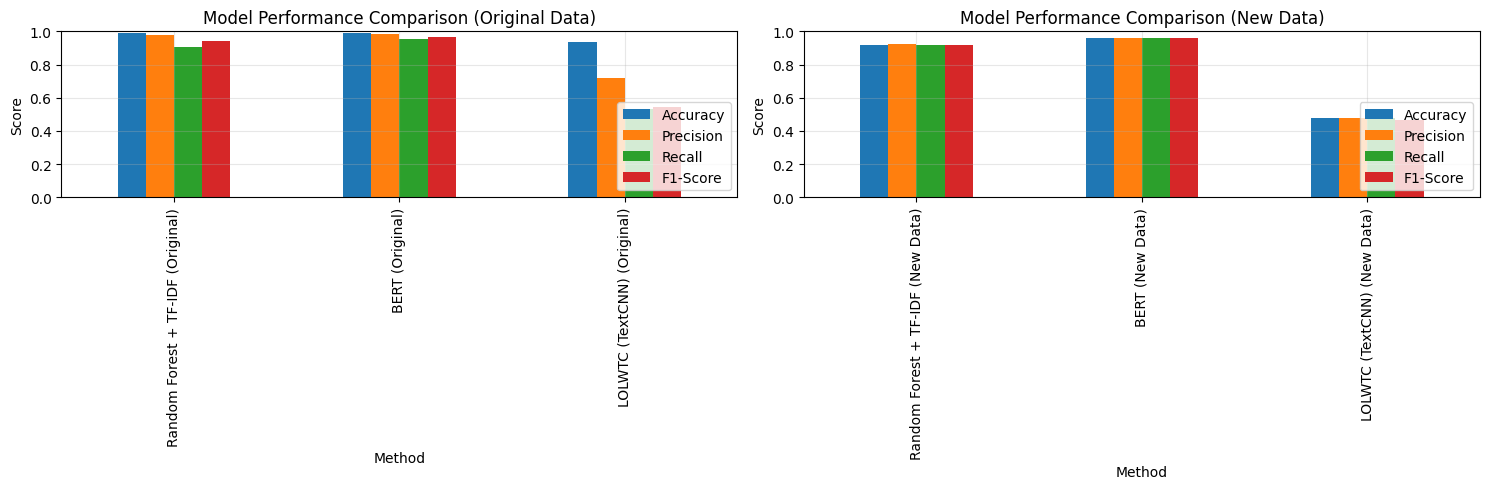


CONCLUSION
According to the paper, LOLWTC achieved an F1 score of 0.9945 on their test set.
Our implementation on the original dataset achieved:
  - BERT F1: 0.9684
  - LOLWTC F1: 0.5446

Our implementation on the NEW VoltTyphoon dataset achieved:
  - Random Forest + TF-IDF F1: 0.9199
  - BERT F1: 0.9600
  - LOLWTC F1: 0.4663

The results may vary due to differences in dataset composition and size.
The paper used a dataset with 1,242 malicious and 9,896 benign samples.


In [65]:
# Create comparison table for the ORIGINAL dataset
comparison_data_original = {
    'Method': ['Random Forest + TF-IDF (Original)', 'BERT (Original)', 'LOLWTC (TextCNN) (Original)'],
    'Accuracy': [results['TF-IDF']['accuracy'], bert_results['accuracy'], lolwtc_results['accuracy']],
    'Precision': [results['TF-IDF']['precision'], bert_results['precision'], lolwtc_results['precision']],
    'Recall': [results['TF-IDF']['recall'], bert_results['recall'], lolwtc_results['recall']],
    'F1-Score': [results['TF-IDF']['f1'], bert_results['f1'], lolwtc_results['f1']]
}
comparison_df_original = pd.DataFrame(comparison_data_original)

# Create comparison table for the NEW dataset
comparison_data_new = {
    'Method': ['Random Forest + TF-IDF (New Data)', 'BERT (New Data)', 'LOLWTC (TextCNN) (New Data)'],
    'Accuracy': [results['TF-IDF_new_data']['accuracy'], results['BERT_new_data']['accuracy'], results['LOLWTC_new_data']['accuracy']],
    'Precision': [results['TF-IDF_new_data']['precision'], results['BERT_new_data']['precision'], results['LOLWTC_new_data']['precision']],
    'Recall': [results['TF-IDF_new_data']['recall'], results['BERT_new_data']['recall'], results['LOLWTC_new_data']['recall']],
    'F1-Score': [results['TF-IDF_new_data']['f1'], results['BERT_new_data']['f1'], results['LOLWTC_new_data']['f1']]
}
comparison_df_new = pd.DataFrame(comparison_data_new)

print("\n" + "="*60)
print("COMPARISON OF METHODS ON ORIGINAL DATASET")
print("="*60)
print(comparison_df_original.round(4))

print("\n" + "="*60)
print("COMPARISON OF METHODS ON NEW VOLTTYPHOON DATASET")
print("="*60)
print(comparison_df_new.round(4))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot for metrics comparison (Original Data)
ax1 = axes[0]
comparison_df_original.set_index('Method')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', ax=ax1)
ax1.set_title('Model Performance Comparison (Original Data)')
ax1.set_ylabel('Score')
ax1.set_xlabel('Method')
ax1.set_ylim([0, 1])
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Bar plot for metrics comparison (New Data)
ax2 = axes[1]
comparison_df_new.set_index('Method')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', ax=ax2)
ax2.set_title('Model Performance Comparison (New Data)')
ax2.set_ylabel('Score')
ax2.set_xlabel('Method')
ax2.set_ylim([0, 1])
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CONCLUSION")
print("="*60)
print(f"According to the paper, LOLWTC achieved an F1 score of 0.9945 on their test set.")
print(f"Our implementation on the original dataset achieved:")
print(f"  - BERT F1: {bert_results['f1']:.4f}")
print(f"  - LOLWTC F1: {lolwtc_results['f1']:.4f}")
print(f"\nOur implementation on the NEW VoltTyphoon dataset achieved:")
print(f"  - Random Forest + TF-IDF F1: {results['TF-IDF_new_data']['f1']:.4f}")
print(f"  - BERT F1: {results['BERT_new_data']['f1']:.4f}")
print(f"  - LOLWTC F1: {results['LOLWTC_new_data']['f1']:.4f}")
print(f"\nThe results may vary due to differences in dataset composition and size.")
print(f"The paper used a dataset with 1,242 malicious and 9,896 benign samples.")

#Tests the above models with the New Datasets ( VoltTyphoon)


In [54]:
new_test_data_path = '/content/final_balanced_volttyphoon_dataset.csv'
new_df = None

try:
    # Attempt to load with comma delimiter, using python engine for robustness
    print(f"Attempting to load '{new_test_data_path}' with comma delimiter, python engine, quotechar='\"' and warning on bad lines...")
    new_df = pd.read_csv(new_test_data_path, sep=',', engine='python', quotechar='"', on_bad_lines='warn')

    # Check if comma delimiter resulted in more than one column
    if new_df.shape[1] <= 1:
        raise ValueError("Comma delimiter resulted in a single column. Trying tab delimiter.")

except (pd.errors.ParserError, ValueError) as e:
    print(f"Comma delimiter failed or resulted in single column: {e}. Trying tab delimiter with python engine, quotechar='\"' and warning on bad lines...")
    try:
        # Attempt to load with tab delimiter, using python engine for robustness
        new_df = pd.read_csv(new_test_data_path, sep='\t', engine='python', quotechar='"', on_bad_lines='warn')

        # Check if tab delimiter resulted in more than one column
        if new_df.shape[1] <= 1:
            raise ValueError("Tab delimiter also resulted in a single column. Could not determine correct delimiter.")

    except (pd.errors.ParserError, ValueError) as e:
        print(f"Tab delimiter also failed or resulted in single column: {e}")
        print("Error: Could not load the CSV file. Please check the file path and delimiter.")
        new_df = None

# Display basic information if DataFrame was successfully loaded
if new_df is not None:
    print(f"\nSuccessfully loaded data from '{new_test_data_path}'.")

    # Explicitly rename 'Unnamed: 0' to 'Command' and 'Unnamed: 4' to 'Label'
    # based on the observed structure of the CSV and print statements
    if 'Unnamed: 0' in new_df.columns and 'Unnamed: 4' in new_df.columns:
        print("Explicitly renaming 'Unnamed: 0' to 'Command' and 'Unnamed: 4' to 'Label'.")
        new_df.rename(columns={'Unnamed: 0': 'Command', 'Unnamed: 4': 'Label'}, inplace=True)
        # Drop other Unnamed columns if they are empty or not needed
        cols_to_drop = [col for col in new_df.columns if col.startswith('Unnamed:') and col not in ['Command', 'Label']]
        if cols_to_drop:
            new_df.drop(columns=cols_to_drop, inplace=True)

    # Handle cases where the header might be malformed or columns need renaming
    # This part of the code will now run after explicit renaming, but the logic below it is not strictly needed
    # as 'Command' and 'Label' should now be correctly set.
    if 'Command' in new_df.columns and 'Label' in new_df.columns:
        # Ensure 'label' column is numeric if it's supposed to be
        new_df['Label'] = pd.to_numeric(new_df['Label'], errors='coerce')
    elif new_df.shape[1] == 1 and new_df.columns[0] == 'Command,Label':
        print("Detected single column 'Command,Label' after loading, attempting to split...")
        new_df[['Command', 'Label']] = new_df['Command,Label'].str.split(',', n=1, expand=True)
        new_df = new_df.drop(columns=['Command,Label'])
        new_df['Label'] = pd.to_numeric(new_df['Label'], errors='coerce')
    elif new_df.shape[1] == 2 and (new_df.columns[0].lower() != 'command' or new_df.columns[1].lower() != 'label'):
        print("Renaming columns to 'Command' and 'Label'.")
        new_df.columns = ['Command', 'Label']
        new_df['Label'] = pd.to_numeric(new_df['Label'], errors='coerce')

    print(f"DataFrame shape: {new_df.shape}")
    print(f"\nColumn names: {new_df.columns.tolist()}")
    print(f"\nFirst 5 rows:\n{new_df.head()}")
    print(f"\nDataFrame Info:")
    new_df.info()
else:
    print("DataFrame could not be loaded.")

Attempting to load '/content/final_balanced_volttyphoon_dataset.csv' with comma delimiter, python engine, quotechar='"' and warning on bad lines...

Successfully loaded data from '/content/final_balanced_volttyphoon_dataset.csv'.
DataFrame shape: (50, 2)

Column names: ['command', 'label']

First 5 rows:
                                             command  label
0  wmic.exe process call create "cmd.exe /c ntdsu...      1
1  ftp/getmac.exe /s srvmain /u maindom\hiropln /...      0
2  lbpolicy set lun type=<type> [paths=<path>-{pr...      0
3                    tftp.exe  -i Host1 get boot.img      0
4  cmd.exe /c "netsh.exe interface portproxy add ...      1

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   command  50 non-null     object
 1   label    50 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 932.0+ bytes


## Handle Missing Values

### Subtask:
Inspect the loaded DataFrame for any missing values (empty fields) and handle them appropriately, for example, by dropping rows with missing 'command' values or filling them if applicable. Display information about the dataset after handling missing values.


**Reasoning**:
First, I'll print the number of missing values for each column to inspect the current state of `new_df`. Then, I'll drop any rows that have missing values in either the 'Command' or 'Label' columns to clean the dataset.



In [55]:
print("Missing values before handling:")
print(new_df.isnull().sum())

# Drop rows where 'command' column is missing
initial_rows = new_df.shape[0]
new_df.dropna(subset=['command'], inplace=True)
print(f"\nDropped {initial_rows - new_df.shape[0]} rows due to missing 'command' values.")

# Drop rows where 'label' column is missing
initial_rows = new_df.shape[0]
new_df.dropna(subset=['label'], inplace=True)
print(f"Dropped {initial_rows - new_df.shape[0]} rows due to missing 'label' values.")

print(f"\nNew DataFrame shape after handling missing values: {new_df.shape}")
print("\nDataFrame Info after handling missing values:")
new_df.info()

Missing values before handling:
command    0
label      0
dtype: int64

Dropped 0 rows due to missing 'command' values.
Dropped 0 rows due to missing 'label' values.

New DataFrame shape after handling missing values: (50, 2)

DataFrame Info after handling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   command  50 non-null     object
 1   label    50 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 932.0+ bytes


## Preprocess Commands and Extract Features

### Subtask:
Preprocess the 'Command' column of the new DataFrame, extract manual features, and scale the numerical features using the previously fitted scaler.


In [57]:
print("Preprocessing new commands...")
new_df['processed_text'] = new_df['command'].apply(preprocess_command)

print("Extracting manual features for new data...")
new_feature_list = new_df['command'].apply(lambda x: extract_manual_features(x))
new_feature_df = pd.DataFrame(list(new_feature_list))

# Scale numerical features using the previously fitted scaler
# Ensure the columns exist before attempting to scale
if 'cmd_length' in new_feature_df.columns and 'word_count' in new_feature_df.columns:
    print("Scaling numerical features in new data...")
    new_feature_df[['cmd_length', 'word_count']] = scaler.transform(new_feature_df[['cmd_length', 'word_count']])
else:
    print("Warning: 'cmd_length' or 'word_count' not found in new_feature_df. Skipping scaling.")

print(f"\nNew feature DataFrame shape: {new_feature_df.shape}")
print(f"\nExtracted {len(new_feature_df.columns)} features for new data")
print(f"Feature names for new data: {new_feature_df.columns.tolist()}")
print(f"\nFeature statistics for new data:")
print(new_feature_df.describe())

Preprocessing new commands...
Extracting manual features for new data...
Scaling numerical features in new data...

New feature DataFrame shape: (50, 2)

Extracted 2 features for new data
Feature names for new data: ['cmd_length', 'word_count']

Feature statistics for new data:
       cmd_length  word_count
count   50.000000   50.000000
mean     3.204013    3.826299
std      5.597546    5.981749
min     -1.204718   -0.716161
25%      0.308110    0.493454
50%      1.573649    2.129992
75%      2.650085    3.766530
max     22.767794   24.899215


## Evaluate Random Forest (TF-IDF)

### Subtask:
Vectorize the new test data using the fitted TF-IDF vectorizer, combine with manual features, and evaluate the trained Random Forest model. Store the performance metrics.


**Reasoning**:
To evaluate the `rf_tfidf` model on the new test data, I need to first vectorize the text data using the pre-fitted `tfidf_vectorizer`, combine these with the manual features, make predictions, and then calculate the specified evaluation metrics.



In [59]:
print("Vectorizing new test data with TF-IDF...")
X_tfidf_new_test = tfidf_vectorizer.transform(new_df['processed_text'])

print("Combining new TF-IDF features with manual features...")
X_tfidf_new_test_combined = np.hstack([X_tfidf_new_test.toarray(), new_feature_df.values])

print("Making predictions with Random Forest (TF-IDF) on new data...")
y_pred_new_tfidf = rf_tfidf.predict(X_tfidf_new_test_combined)

# Ensure 'label' column is treated as the true labels (y_true)
# Convert 'label' to numpy array for consistency
y_true_new = new_df['label'].values

# Evaluate and store results
new_results_rf_tfidf = {
    'accuracy': accuracy_score(y_true_new, y_pred_new_tfidf),
    'precision': precision_score(y_true_new, y_pred_new_tfidf, average='macro'),
    'recall': recall_score(y_true_new, y_pred_new_tfidf, average='macro'),
    'f1': f1_score(y_true_new, y_pred_new_tfidf, average='macro')
}

# Display results for the new data
print("\nRandom Forest (TF-IDF) Evaluation on New Data:")
print("="*50)
for metric, value in new_results_rf_tfidf.items():
    print(f"{metric.capitalize()}: {value:.4f}")

# Optional: Add to the overall results dictionary for comparison
results['TF-IDF_new_data'] = new_results_rf_tfidf

Vectorizing new test data with TF-IDF...
Combining new TF-IDF features with manual features...
Making predictions with Random Forest (TF-IDF) on new data...

Random Forest (TF-IDF) Evaluation on New Data:
Accuracy: 0.9200
Precision: 0.9227
Recall: 0.9200
F1: 0.9199


**Reasoning**:
Now that the TF-IDF model has been evaluated, I will evaluate the BERT model on the new test data. This involves preparing the new data into a BERTDataset and DataLoader, and then using the previously defined `evaluate_model` function.



In [61]:
print("Preparing new test data for BERT model...")
new_bert_dataset = BERTDataset(
    new_df['processed_text'].values,
    new_feature_df.values,
    new_df['label'].values, # Changed 'Label' to 'label'
    bert_tokenizer,
    max_length=128
)
new_bert_loader = DataLoader(new_bert_dataset, batch_size=16, shuffle=False)

print("Evaluating BERT model on new data...")
new_bert_results = evaluate_model(bert_model, new_bert_loader, "BERT_New_Data", is_bert=True)

# Optional: Add to the overall results dictionary for comparison
results['BERT_new_data'] = new_bert_results

Preparing new test data for BERT model...
Evaluating BERT model on new data...

BERT_New_Data Evaluation Results:
Accuracy: 0.9600
Precision (Macro): 0.9600
Recall (Macro): 0.9600
F1-Score (Macro): 0.9600

Confusion Matrix:
[[24  1]
 [ 1 24]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.96      0.96        25
 LotL Attack       0.96      0.96      0.96        25

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50



**Reasoning**:
Now that the TF-IDF and BERT models have been evaluated, I will evaluate the LOLWTC (TextCNN) model on the new test data. This involves preparing the new data into a TextCNNDataset and DataLoader, and then using the previously defined `evaluate_model` function.



In [64]:
print("Preparing new test data for LOLWTC model...")
new_cnn_dataset = TextCNNDataset(
    prepare_text_for_cnn(new_df['processed_text'].values, word2vec_model),
    new_feature_df.values,
    new_df['label'].values
)
new_cnn_loader = DataLoader(new_cnn_dataset, batch_size=32, shuffle=False)

print("Evaluating LOLWTC model on new data...")
new_lolwtc_results = evaluate_model(lolwtc_model, new_cnn_loader, "LOLWTC_New_Data", is_bert=False)

# Optional: Add to the overall results dictionary for comparison
results['LOLWTC_new_data'] = new_lolwtc_results

Preparing new test data for LOLWTC model...
Evaluating LOLWTC model on new data...

LOLWTC_New_Data Evaluation Results:
Accuracy: 0.4800
Precision (Macro): 0.4777
Recall (Macro): 0.4800
F1-Score (Macro): 0.4663

Confusion Matrix:
[[16  9]
 [17  8]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.48      0.64      0.55        25
 LotL Attack       0.47      0.32      0.38        25

    accuracy                           0.48        50
   macro avg       0.48      0.48      0.47        50
weighted avg       0.48      0.48      0.47        50

